In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("powerplant_data.csv")

In [5]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
# AT - Teamperature
# v = vaccum
# AP = Pressure
# RH = humidity

#PE = produced energy




In [7]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [8]:
x= df.drop("PE", axis=1)
y= df["PE"]

In [9]:
x.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42)




In [11]:
df.shape

(9568, 5)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)



In [13]:
x_test_scaled

array([[ 1.35027377,  0.23835089, -1.2868797 , -1.1152662 ],
       [ 0.81612819,  1.36219539, -0.74354734,  0.25518223],
       [-0.23877586, -0.73921294,  1.9883008 , -0.20689783],
       ...,
       [ 0.23512774,  0.27059555,  0.93538342, -0.23848131],
       [-1.79971257, -1.42106962,  2.6025026 ,  1.16698358],
       [ 1.16285427,  0.78729663, -0.34195385, -0.32361939]])

In [14]:
import torch
import torch.nn as nn


x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)

y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)


In [15]:
type(x_train_scaled)

numpy.ndarray

In [16]:
type(y_train)
y_train.shape

(6697,)

In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [18]:
train_loaded = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loaded = DataLoader(test_dataset, batch_size=32)

Deep Learning

In [19]:
import torch.nn as nn

# Build our ANN Model

class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()
    self.model = nn.Sequential(
        # 1st hidden
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),

        # 2nd hidden
        nn.Linear(6,6),
        nn.ReLU(),

        # output layer
        nn.Linear(6,1),
    )

  def forward(self, x):
    return self.model(x)

In [20]:
import torch.optim as optim


model = ANN()


#loss function, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [22]:
# train the ANN

train_losses = []
val_losses = []

epochs = 100

for epoch in range(epochs):
  model.train()
  running_loss = 0.0  # total training loss for 1 epoch


  for x_batch, y_batch in train_loaded:

    outputs = model(x_batch)                  # forward prop.......predicted outputs for this batch
    loss = criterion(outputs, y_batch)        #  compute loss


    loss.backward()                  # back prop..........compute gradient
    optimizer.step()                 # params update


    running_loss += loss.item()      # loss is a tensor

  epoch_train_loss = running_loss / len(train_loaded)
  train_losses.append(epoch_train_loss)

  # validation
  running_val_loss = 0.0
  model.eval()

  with torch.no_grad():
    for x_batch, y_batch in test_loaded:
      outputs = model(x_batch)
      loss = criterion(outputs, y_batch)
      running_val_loss += loss.item()

  epoch_val_loss = running_val_loss / len(test_loaded)
  val_losses.append(epoch_val_loss)

  print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ==> train loss = 206032.19553571427 & val loss = 204318.93090277776
epoch 2/100 ==> train loss = 199324.19330357143 & val loss = 190893.6201388889
epoch 3/100 ==> train loss = 174641.1710565476 & val loss = 151607.5029513889
epoch 4/100 ==> train loss = 124479.28816964285 & val loss = 96970.17352430556
epoch 5/100 ==> train loss = 82694.11041666666 & val loss = 77102.89105902778
epoch 6/100 ==> train loss = 79208.37933407738 & val loss = 77566.72473958334
epoch 7/100 ==> train loss = 55445.5083984375 & val loss = 34088.34186197917
epoch 8/100 ==> train loss = 21948.551381138393 & val loss = 16332.894357638888
epoch 9/100 ==> train loss = 18021.020540364585 & val loss = 21925.544498697916
epoch 10/100 ==> train loss = 30424.420265997025 & val loss = 38406.37417534722
epoch 11/100 ==> train loss = 47624.79292224703 & val loss = 50253.34752604167
epoch 12/100 ==> train loss = 48462.250967261905 & val loss = 38705.75219184028
epoch 13/100 ==> train loss = 28239.046507626488 & v

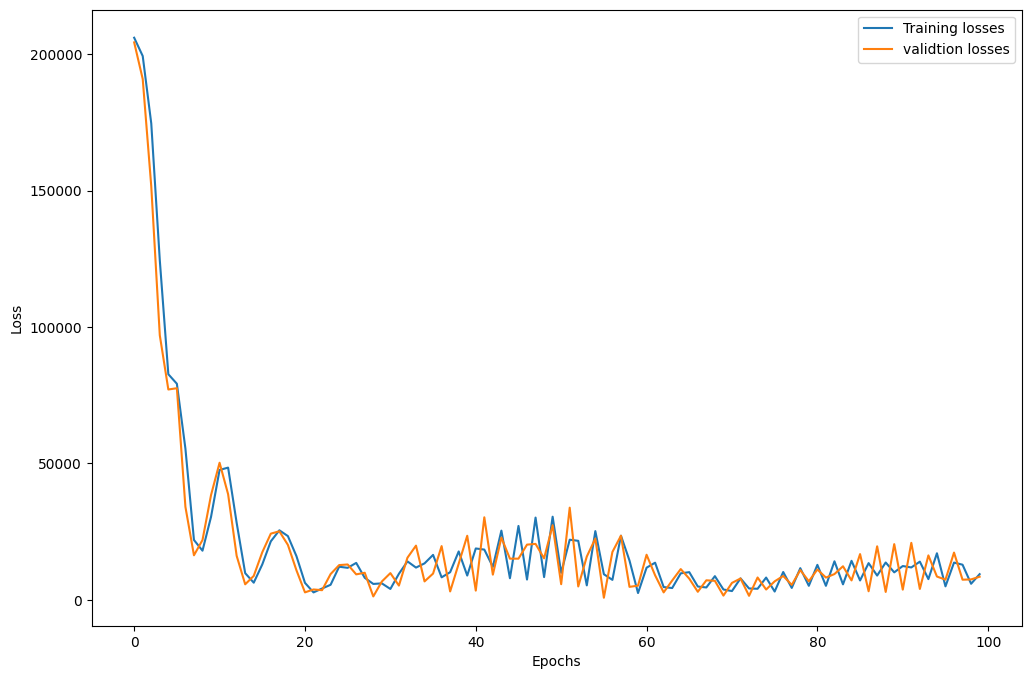

In [23]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_losses" : train_losses,
    "val_losses": val_losses})

plt.figure(figsize=(12,8))
plt.plot(loss_df["train_losses"], label="Training losses")
plt.plot(loss_df["val_losses"], label="validtion losses")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


In [24]:
# Evaluation

model.eval()
with torch.no_grad():
  train_pred = model(x_train_tensor)
  test_pred = model(x_test_tensor)

  train_mse_loss = criterion(train_pred, y_train_tensor)
  test_mse_loss = criterion(test_pred, y_test_tensor)

print("Training MSE", train_mse_loss.item())
print("Testing MSE", test_mse_loss.item())


Training MSE 8995.1962890625
Testing MSE 8483.5908203125


In [25]:
from sklearn.metrics import r2_score

print("r^2 score",  r2_score(y_test, test_pred))

r^2 score -28.460289446031496


In [28]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual"])
pd.concat([predicted_df, actual_df], axis=1)

,Predicted,Actual
0,494.379883,433.27
1,437.980560,438.16
2,488.790497,458.42
3,726.920044,480.82
4,445.112396,441.41
...,...,...
2866,684.265259,480.31
2867,476.691620,446.77
2868,429.192902,454.66
2869,822.048828,483.77
